# Accuracy of IDF evacuation orders in Gaza

In [20]:
!pip install deep-translator langchain langchain-google-genai dotenv geopandas folium


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [72]:
# Install dependencies
import os
import time
import asyncio
from dotenv import load_dotenv
import re
import pandas as pd
from deep_translator import GoogleTranslator
from datetime import datetime, timedelta
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain.chains import LLMChain
import geopandas as gpd
import folium
from shapely.ops import unary_union
from shapely.geometry import MultiPolygon
from shapely.geometry import Point
import matplotlib.pyplot as plt

## 1. Displacements

The [Gaza Maps](https://gazamaps.com/) project maintains a database of all known IDF evacuation orders issued on official IDF Arabic channels, or via leaflets in Gaza. 

In [ ]:
# Load the displacement data
displacement = pd.read_csv("data/csv/displacement_updated.csv")
displacement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     112 non-null    object 
 1   x_source                 96 non-null     object 
 2   x_text                   96 non-null     object 
 3   x_text_translated        96 non-null     object 
 4   x_timestamp_utc3         96 non-null     object 
 5   evacuation_zone_prompt   109 non-null    object 
 6   facebook_source          22 non-null     object 
 7   facebook_timestamp_utc3  22 non-null     object 
 8   leaflet                  19 non-null     object 
 9   leaflet_text_translated  18 non-null     object 
 10  safezone_prompt          109 non-null    object 
 11  link                     98 non-null     object 
 12  map_idf                  98 non-null     object 
 13  map_full                 82 non-null     object 
 14  map_zoom                 8

### Data cleaning
1. Remove the URL at the end of every tweet in the column `x_text`.
2. Translate every tweet from Arabic to English, creating a new column `x_text_translated`.
3. Convert the column `x_timestamp` to UTC+3, which is the timezone in Gaza.

In [23]:
def remove_urls(text):
    """Remove all URLs from the text."""
    if pd.isna(text) or not isinstance(text, str):
        return text # Leave non-string types unchanged
    return re.sub(r'https://\S+', '', text).strip()
    

def arabic_to_english(text):
    """Translate Arabic text to English."""
    if pd.isna(text) or not isinstance(text, str):
        return text
    try:
        return GoogleTranslator(source='ar', target='en').translate(text)
    except Exception as e:
        print(f"Error translating text: {text} - {e}")
        return text


def convert_date(time_str):
    """Convert a Twitter-style timestamp to hour:minute in UTC+3."""
    if pd.isna(time_str) or not isinstance(time_str, str):
        return time_str
    try:
        # Parse the original UTC datetime string
        dt = datetime.strptime(time_str, "%a %b %d %H:%M:%S %z %Y")     
        # Add 3 hours to get UTC+3
        dt_utc3 = dt + timedelta(hours=3)       
        # Format hour and minute
        time_formatted = dt_utc3.strftime("%H:%M")
        return time_formatted
    except Exception as e:
        print(f"Skipping malformed timestamp '{time_str}': {e}")
        return time_str
    
    
def clean_displacement_blocks(block):
    """
    Convert a comma-separated string of numbers (ints or floats) 
    to integers (as strings), removing decimals.
    """
    if not isinstance(block, str):
        return block  # Skip non-string entries (e.g. NaN)

    cleaned = []
    for item in block.split(","):
        item = item.strip()
        if item == "":
            continue
        try:
            # Convert to float, then to int (removes decimals)
            number = int(float(item))
            cleaned.append(str(number))
        except ValueError:
            cleaned.append(item)  # keep original if not a number
    return ", ".join(cleaned)

In [24]:
# Remove URLs from the tweet text
displacement['x_text'] = displacement['x_text'].apply(remove_urls)

# Translate Arabic tweets to English
# displacement['x_text_translated'] = displacement['x_text'].apply(arabic_to_english)

# Convert the timestamp to UTC+3 hour:minute format
# displacement['x_timestamp_utc3'] = displacement['x_timestamp'].apply(convert_date)

# Clean the block numbers
displacement["displacement_blocks"] = displacement["displacement_blocks"].apply(clean_displacement_blocks)

# Remove useless columns
displacement = displacement.drop(['evacuation_zone_prompt', 'safezone_prompt', 'map_full', 'map_zoom'], axis=1)

displacement.head(3)

,date,x_source,x_text,x_text_translated,x_timestamp_utc3,facebook_source,facebook_timestamp_utc3,leaflet,leaflet_text_translated,link,map_idf,displacement_blocks,labeled_safe_blocks,evacuation_zone,safezone,area_sq_km_displacement,area_sq_km_labeled_safe
0,2025-06-02,https://x.com/AvichayAdraee/status/19295702495...,"#عاجل ‼️ إلى جميع المتواجدين في البلوكات 47, 1...","To all those present in blocks 47, 106, 108, 1...",19:06,https://www.facebook.com/IDFarabicAvichayAdrae...,19:07,NaN,NaN,https://gazamaps.com/displacement/108,https://gazamaps.com/storage/displacement-maps...,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,...",NaN,Khan Yunis Governate,Al Mawasi,169.29,0.0
1,2025-05-31,https://x.com/avichayadraee/status/19288790357...,#عاجل ‼️إلى جميع سكان خانيونس وبني سهيلا وعبسا...,"To all residents of Khan Yunis, Bani Suhaila a...",21:19,NaN,NaN,NaN,NaN,https://gazamaps.com/displacement/107,https://gazamaps.com/storage/displacement-maps...,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,...",NaN,"Khan Yunis, Bani Suhaila, Abasan",Mawasi,168.36,0.0
2,2025-05-29,https://x.com/avichayadraee/status/19281887521...,#عاجل ‼️ الى جميع سكان قطاع غزة المتواجدين في ...,To all residents of the Gaza Strip located in ...,23:36,NaN,NaN,NaN,NaN,https://gazamaps.com/displacement/106,https://gazamaps.com/storage/displacement-maps...,"321, 568, 569, 570, 571, 572, 573, 574, 575, 5...",NaN,"Gaza Strip, Al-Atatra, Jabalia Al-Balad, Shuj...",west,95.31,0.0


The tweet text `x_text_translated` contains the names of the locations designated to be evacuated, and the locations where residents should find shelter. We will use an LLM to extract these locations and put them in separate columns for further analysis.

> Note: Method currently not working. We used the SheetGPT extension for Google Sheets instead with the same prompts.

In [ ]:
try:
    # Load Google Gemini API key
    dotenv_path = os.path.abspath(os.path.join(os.getcwd(), '..', '.env'))
    load_dotenv(dotenv_path)

    google_api_key = os.getenv("GOOGLE_API_KEY")
except:
    google_api_key = input("Your Google API key: ")

# Set up the LLM
llm = GoogleGenerativeAI(model="gemini-2.0-flash", google_api_key=google_api_key)

# Global delay tracker
last_call_time = 0

async def throttled_llm_run(chain, input_data, delay=4):
    """Run LLM chain with rate limit delay (default: 4 seconds)."""
    global last_call_time

    now = time.time()
    time_since_last = now - last_call_time

    if time_since_last < delay:
        await asyncio.sleep(delay - time_since_last)
    
    try:
        result = chain.run(x_text_translated=input_data).strip()
        last_call_time = time.time()  # Update the last call time
        return result
    except Exception as e:
        print(f"Error running LLM chain: {e}")
        return None

In [ ]:
async def extract_evacuations(row):
    """Function to extract the names of locations designated to be evacuated from a tweet."""
    prompt = PromptTemplate.from_template("""
    You will be given a tweet containing an evacuation order to people in specific locations.
    Name the affected locations (not the block numbers, if present in the tweet) where people are ordered to evacuate from, separated by commas.
    If the location names where people should evacuate from are not mentioned in the tweet, answer "Unknown".
    Do not include the area which people are ordered to evacuate to.
                                          
    Tweet: {x_text_translated}
    """)

    chain = LLMChain(llm=llm, prompt=prompt)

    if isinstance(row['x_text_translated'], str):
        # Prompt the LLM to extract evacuation locations
        return await throttled_llm_run(chain, row['x_text_translated'])
    return None


async def extract_safezones(row):
    """Function to extract the names of safe zones from a tweet."""
    prompt = PromptTemplate.from_template("""
    You will be given a tweet containing an evacuation order to people in specific locations.
    Name the safe zones (not the block numbers, if present in the tweet) where people are ordered to evacuate to, separated by commas.
    If the safe zones where people should evacuate to are not mentioned in the tweet, answer "Unknown".
    Do not include the area which people are ordered to evacuate from.
                                          
    Tweet: {x_text_translated}
    """)

    chain = LLMChain(llm=llm, prompt=prompt)

    if isinstance(row['x_text_translated'], str):
        # Prompt the LLM to extract safe zone locations
        return await throttled_llm_run(chain, row['x_text_translated'])
    return None

In [ ]:
# Extract evacuation locations from the translated tweets
# displacement["locations"] = displacement.apply(extract_evacuations, axis=1)

# Extract safe zones from the translated tweets
# displacement["safezones"] = displacement.apply(extract_safezones, axis=1)

## 2. Political violence events

ACLED's [Gaza Monitor](https://acleddata.com/gaza-monitor/#1738833681742-00591c0f-83dc) contains a map and accompanying dataset of all political violence events, demonstration events, and strategic developments recorded in Israel and Palestine started from 7 October 2023.

In [ ]:
# Load the ACLED data
acled = pd.read_csv("data/csv/acled_may23.csv")
acled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90242 entries, 0 to 90241
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id_cnty       90242 non-null  object 
 1   event_date          90242 non-null  object 
 2   year                90242 non-null  int64  
 3   time_precision      90242 non-null  int64  
 4   disorder_type       90242 non-null  object 
 5   event_type          90242 non-null  object 
 6   sub_event_type      90242 non-null  object 
 7   actor1              90242 non-null  object 
 8   assoc_actor_1       20743 non-null  object 
 9   inter1              90242 non-null  object 
 10  actor2              66166 non-null  object 
 11  assoc_actor_2       16778 non-null  object 
 12  inter2              66166 non-null  object 
 13  interaction         90242 non-null  object 
 14  civilian_targeting  21230 non-null  object 
 15  iso                 90242 non-null  int64  
 16  regi

### Data cleaning

The [ACLED Codebook](https://acleddata.com/acleddatanew/wp-content/uploads/dlm_uploads/2024/10/ACLED-Codebook-2024-7-Oct.-2024.pdf) contains more information about how ACLED codes and catagorizes data. Based on this we will filter the dataset to only include battles, explosions/remote violence and violence against civilians by the IDF in Gaza after 7 October 2023:

1. Only include dates in the column `event_date` after 2023-10-07.
2. Only include datapoints for 'Political violence' in the column `disorder_type`. Only include the following subcategories within the column `event_type`:
    - Battles
    - Explosions/Remote violence
    - Violence against civilians
3. Only include datapoints that contain 'Military Forces of Israel' in the column `actor1`.
4. Only include datapoints for the location 'Gaza Strip' in the column `admin1`.

In [26]:
# Ensure event_date is in datetime format
acled["event_date"] = pd.to_datetime(acled["event_date"], errors='coerce')

# Filter events types
event_types = ["Battles", "Explosions/Remote violence", "Violence against civilians"]

# Apply filters
acled_filtered = acled[
    (acled["event_date"] > pd.Timestamp("2023-10-07")) &
    (acled["disorder_type"] == "Political violence") &
    (acled["event_type"].isin(event_types)) &
    (acled["actor1"].str.contains("Military Forces of Israel", na=False)) &
    (acled["admin1"] == "Gaza Strip")
]

acled_filtered.head(3)

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
4,PSE74167,2025-05-23,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),NaN,External/Other forces,...,Jabalya,31.5272,34.4835,2,Newpress; Palestine News and Information Agenc...,New media-National,"On 23 May 2025, Israeli warplanes targeted a g...",3,NaN,1748304023
5,PSE74182,2025-05-23,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),NaN,External/Other forces,...,Gaza - Southern Remal,31.5168,34.4355,2,Quds News Network,National,"On 23 May 2025, Israeli warplanes targeted sev...",0,NaN,1748304023
6,PSE74194,2025-05-23,2025,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),NaN,External/Other forces,...,An Nusayrat,31.4486,34.3925,1,Palestine News and Information Agency; Quds Ne...,National,"On 23 May 2025, Israeli warplanes targeted the...",3,NaN,1748304023


## 3. Mapping the block numbers to coordinates

The `idf_blocks.geojson` file provides polygon coordinates for each of the block numbers designated by the IDF. We will attach the coordinates from the GEOJSON to the corresponding block numbers in the `displacement` dataset.

In [ ]:
gdf = gpd.read_file("data/json/idf_blocks.geojson")
gdf.head(3)

,descriptio,remarks,population,block,wkt,manpower_e,הערות,חמולה,כמותמ,כמותת,...,צפיפו,שטחבמ,שטחבק,sum_tkifot,last_updat,צפיפ_1,num_reside,st_area_sh,st_length_,geometry
0,ע'זה אלזיתונ,השכבה המבצעית,48,655,MULTIPOLYGON (((34.4422370199999932 31.4504822...,76,None,"משפחת אבו סעיד-38 אנשים בבלוק,44% המשפחה בבלוק...",15.0,85.0,...,0.000093,9.135208e+05,0.913521,46,2023-10-09,0.0,20.4,0.000087,0.039979,"POLYGON ((34.44224 31.45048, 34.44129 31.44188..."
1,ע'זה,השכבה המבצעית,10797,770,MULTIPOLYGON (((34.4535920910000186 31.5386595...,76,None,"משפחת אבו ריאלה'-349 אנשים בבלוק,3% המשפחה בבל...",1005.0,11528.0,...,0.053244,2.165146e+05,0.216515,158,2023-10-30,0.0,2766.7,0.000021,0.019794,"POLYGON ((34.45359 31.53866, 34.45124 31.53659..."
2,רפח,השכבה המבצעית,9,2372,MULTIPOLYGON (((34.2646000319999757 31.3141579...,10,None,"משפחת שלופ-6 אנשים בבלוק,100% המשפחה בבלוק,דיר...",4.0,20.0,...,0.000014,1.406278e+06,1.406278,6,2023-11-16,0.0,20.0,0.000133,0.045739,"POLYGON ((34.2646 31.31416, 34.26137 31.31029,..."


In [41]:
def map_geometry_to_blocks(displacement_df, gdf):
    """
    For each row in the displacement dataframe, match all blocks listed in the column
    'displacement_blocks' to the 'block' field in gdf and collect matching geometries.
    Returns a copy of the displacement dataframe with a new 'geometry_polygon' column (as MultiPolygon if needed).
    """

    # Ensure gdf['block'] is int
    gdf["block"] = gdf["block"].astype(int)

    # Build a dictionary for fast lookup: block_num -> geometry
    block_to_geom = dict(zip(gdf["block"], gdf["geometry"]))

    geometries = []
    for blocks_str in displacement_df["displacement_blocks"]:
        if not isinstance(blocks_str, str):
            geometries.append(None)
            continue

        # Convert to list of ints
        try:
            block_nums = [int(float(b.strip())) for b in blocks_str.split(',') if b.strip()]
        except ValueError:
            block_nums = []
        
        # Collect matching geometries
        matched_geoms = [block_to_geom[b] for b in block_nums if b in block_to_geom]

        if matched_geoms:
            # Combine into single MultiPolygon or keep as-is
            unified = unary_union(matched_geoms)
            geometries.append(unified)
        else:
            geometries.append(None)

    # Return updated dataframe
    result = displacement_df.copy()
    result['geometry_polygon'] = geometries
    return result

In [42]:
displacement_with_geometry = map_geometry_to_blocks(displacement, gdf)

# Extract geometry and center the map on it
single_geom = displacement_with_geometry.loc[2, 'geometry_polygon']
centroid = single_geom.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=15)

# Convert to GeoDataFrame to display with folium
gdf_row = gpd.GeoDataFrame(geometry=[single_geom], crs="EPSG:4326")

folium.GeoJson(gdf_row).add_to(m)
m

### Attacks within evacuation zones on the same (or next) day as the IDF order

In [70]:
# Create point geometries
acled_filtered['geometry_point'] = acled_filtered.apply(
    lambda row: Point(row['longitude'], row['latitude']), axis=1
)
acled_gdf = gpd.GeoDataFrame(acled_filtered, geometry='geometry_point', crs="EPSG:4326")

# Normalize both columns to date only
acled_gdf['event_date'] = pd.to_datetime(acled_gdf['event_date']).dt.date
displacement_with_geometry['date'] = pd.to_datetime(displacement_with_geometry['date']).dt.date

def match_point_with_polygon_on_date(row, displacement_df):
    """Check whether the point in the row in within any polygon in displacement_df on the same or next day."""
    date = row['event_date']
    next_day = date + timedelta(days=1)

    # Filter polygons where date is same or next day
    same_or_next_day_polygons = displacement_df[
        (displacement_df['date'] == date) | (displacement_df['date'] == next_day)
    ]

    for _, poly_row in same_or_next_day_polygons.iterrows():
        geom = poly_row.get("geometry_polygon")
        if geom is not None and geom.contains(row["geometry_point"]):
            return True

    return False

acled_gdf['inside_displacement_polygon'] = acled_gdf.apply(
    lambda row: match_point_with_polygon_on_date(row, displacement_with_geometry), axis=1
)

/var/folders/hk/7vk84b7s5wx3wh1q4wt5_btw0000gn/T/ipykernel_83709/1303797381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acled_filtered['geometry_point'] = acled_filtered.apply(


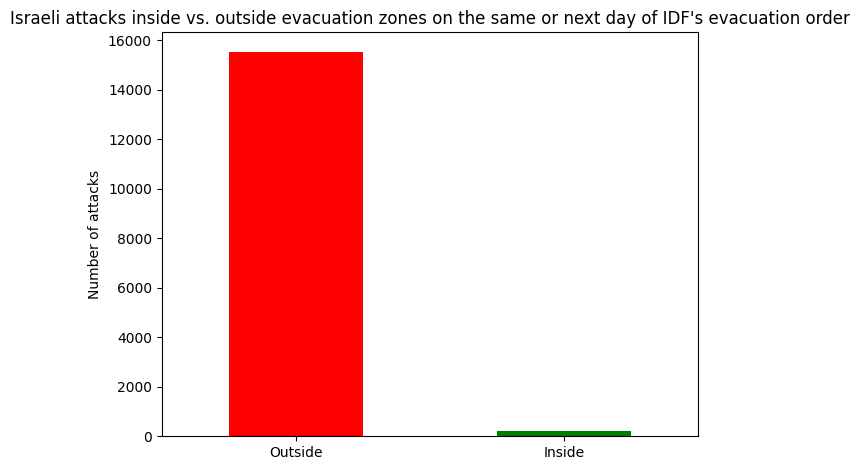

In [79]:
# Count True/False and rename index
counts = acled_gdf['inside_displacement_polygon'].value_counts()
counts.index = ['Outside' if val == False else 'Inside' for val in counts.index]

# Plot
counts.plot(kind='bar', color=['red', 'green'])
plt.title("Israeli attacks inside vs. outside evacuation zones on the same or next day of IDF's evacuation order")
plt.xlabel('')
plt.ylabel('Number of attacks')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()